## Comparando modelos utilizando as métricas de avaliação de modelos

In [9]:
!pip install scikit-learn

import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import Lasso

Importando o Dataset

In [10]:
from sklearn import datasets
data  = datasets.load_diabetes()
X = data.data # variavel preditoras
y = data.target # variável resposta 
feature_names = data.feature_names

Contextualização:

O conjunto de dados de diabetes usado neste exemplo é proveniente do sklearn.datasets. As variáveis presentes no conjunto de dados são:

*   age: Idade do paciente.
*   sex: Gênero do paciente (0: feminino, 1: masculino).
*   bmi: Índice de massa corporal (IMC).
*   bp: Pressão arterial média.
*   s1: Total de soro de lipoproteína de alta densidade (HDL).
*   s2: Total de soro de lipoproteína de baixa densidade (LDL).
*   s3: Total de soro de triglicerídeos.
*   s4: Total de soro de total de lipoproteína.
*   s5: Total de soro de ácido sérico.
*   s6: Total de soro de lamotrigina.
Cada uma dessas variáveis representa diferentes características médicas e fisiológicas dos pacientes.

O objetivo é prever a medida quantitativa da progressão da doença diabética após um ano com base nessas características. O valor alvo (target) é uma medida quantitativa da progressão da doença.

Verificando os dados carregados

In [11]:
data.feature_names #nome das variaveis

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [12]:
data.data.shape  #tamanho da base de dados

(442, 10)

In [13]:
data.target.shape

(442,)

Criando um data frame para iniciar as analises

In [14]:
db_df = pd.DataFrame(data.data,columns=data.feature_names)

In [15]:
db_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [16]:
db_df['progressao'] = data.target

In [17]:
X = pd.DataFrame(db_df, columns=data.feature_names)
y = pd.DataFrame(data.target, columns=['progressao'])

In [18]:
y

,progressao
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


In [19]:
db_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progressao
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [20]:
db_df.isna().sum() #verificando valores ausentes

age           0
sex           0
bmi           0
bp            0
s1            0
s2            0
s3            0
s4            0
s5            0
s6            0
progressao    0
dtype: int64

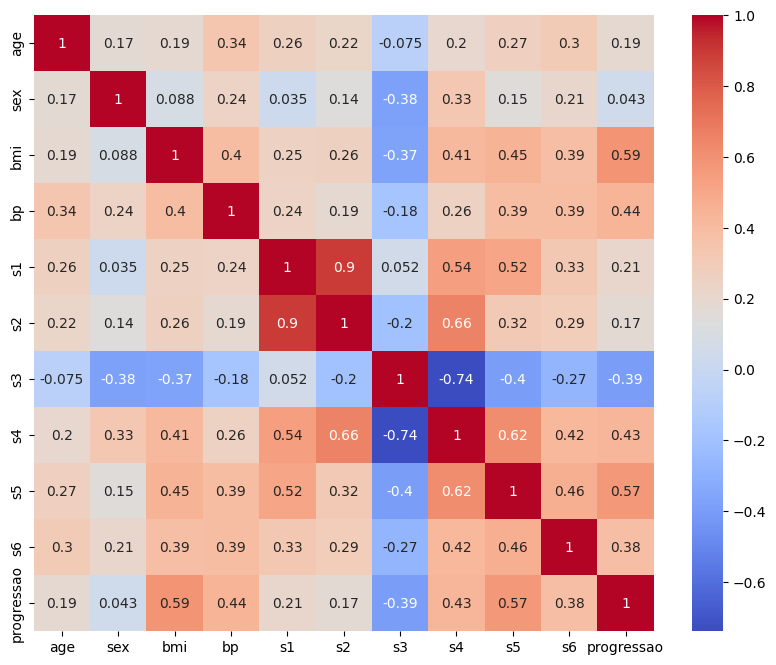

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(db_df.corr(), cmap='coolwarm', annot=True)
plt.show()

Maiores correlações com a progressão :
   - bmi : 0.59
   - s5 : 0.57
   - bp : 0.44
   - s4 : 0.43
   - s3: 0.39

   -   ['bmi', 's5', 'bp', 's1', 's2', 'sex']

Divisão da base - Treino e Teste

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
def calculate_aic(model, X, y):
    n = len(y)
    k = X.shape[1] + 1  # número de parâmetros, incluindo o intercepto
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    aic = n * np.log(mse) + 2 * k
    return aic

Iremos criar as seguintes variáveis:

- selected_features: Lista que armazenará as variáveis selecionadas durante o procedimento.
- stepwise_model: Modelo de regressão linear a ser ajustado.
- best_aic: Variável que armazenará o menor AIC encontrado.

No python é necessário criar a função para realizar o stepwise

In [24]:
def forward_backward_stepwise_selection(X, y):
    selected_features = [] # lista vazia que armazenará as variáveis selecionadas
    stepwise_model = LinearRegression() # modelo de regressão a ser usado
    best_aic = float('inf') # variável que armazenará o melhor AIC
    #(lembrando que quanto menor o AIC, melhor o modelo)
    
    # Passo Forward
    while True: #Este loop continua até que não haja mais variáveis para serem testadas.
        features_to_test = [feature for feature in X.columns if feature not in selected_features]
        if not features_to_test: #Lista das variáveis que ainda não foram selecionadas.
            break
        
        best_feature = None
        best_model = None
        best_aic_with_new_feature = float('inf')
        
        #Para cada variável em features_to_test, o modelo linear é ajustado utilizando essa variável em 
        #conjunto com as variáveis já selecionadas.
        for feature in features_to_test:
            # Ajusta o modelo com a nova variável adicionada
            features_selected = selected_features + [feature]
            stepwise_model.fit(X[features_selected], y)
            # Calcula o AIC
            aic = calculate_aic(stepwise_model, X[features_selected], y)
            # Seleciona a variável com menor AIC
            if aic < best_aic_with_new_feature:
                best_aic_with_new_feature = aic
                best_feature = feature
                best_model = stepwise_model
                
        if best_aic_with_new_feature >= best_aic:
            break
        
        selected_features.append(best_feature)
        best_aic = best_aic_with_new_feature
    
    # Passo Backward
    while True:
        if not selected_features:
            break
        
        worst_feature = None
        worst_model = None
        best_aic_without_feature = float('inf')
        
        for feature in selected_features:
            # Ajusta o modelo sem a variável atual
            features_removed = [f for f in selected_features if f != feature]
            stepwise_model.fit(X[features_removed], y)
            # Calcula o AIC
            aic = calculate_aic(stepwise_model, X[features_removed], y)
            # Seleciona a variável com menor AIC
            if aic < best_aic_without_feature:
                best_aic_without_feature = aic
                worst_feature = feature
                worst_model = stepwise_model
        
        if best_aic_without_feature >= best_aic:
            break
        
        selected_features.remove(worst_feature)
        best_aic = best_aic_without_feature
    
    return selected_features

In [25]:
# Inicializa o modelo de regressão linear
stepwise_model = LinearRegression()

# Realiza a seleção de variáveis
selected_features = forward_backward_stepwise_selection(X_train,y_train )

# Exibe as variáveis selecionadas
print("Variáveis Selecionadas:", selected_features)


Variáveis Selecionadas: ['bmi', 's5', 'bp', 's1', 's2', 'sex']


In [26]:
# Treinamento do modelo final usando as variáveis selecionadas
X_train_stepwise = X_train[selected_features]
X_test_stepwise = X_test[selected_features]

In [27]:
results = []

In [28]:
model_stepwise = LinearRegression()
model_step = model_stepwise.fit(X_train_stepwise, y_train)# Calcular métricas de avaliação
mae = np.mean(np.abs(y_test - model_step.predict(X_test_stepwise)))
mse = np.mean((y_test - model_step.predict(X_test_stepwise)) ** 2)


# Calcular o número de observações e o número de variáveis
n_obs = len(y_test)
n_vars = len(selected_features)

# Calcular o AIC e o BIC manualmente
aic = n_obs * np.log(mse) + 2 * n_vars
bic = n_obs * np.log(mse) + n_vars * np.log(n_obs)


r_squared = model_stepwise.score(X_test_stepwise, y_test)

# Adicionar as métricas ao resultado
results.append({
    'Modelo': 'Modelo 1',
    'MAE': mae,
    'MSE': mse,
    'AIC': aic,
    'BIC': bic,
    'R²': r_squared
})

# Imprimir as métricas
print("Métricas do Modelo 1:")
print("MAE:", mae)
print("MSE:", mse)
print("AIC:", aic)
print("BIC:", bic)
print("R²:", r_squared)

Métricas do Modelo 1:
MAE: 42.61109010231694
MSE: 2846.2905242137595
AIC: 719.8856950979241
BIC: 734.817513316317
R²: 0.4627767079320301


Observe que os métodos utilizados para gerar o modelo na comparação das métricas x o gerado agora utilizam metodologias de treinamento diferente. 

In [29]:
lm6 = sm.OLS.from_formula("progressao ~ bmi + s5 + bp + s1 + s2 + sex", data=db_df)
model_6 = lm6.fit()
print("Análise do Modelo:")
print(model_6.summary())
print("=" * 80)

Análise do Modelo:
                            OLS Regression Results                            
Dep. Variable:             progressao   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     76.95
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           3.01e-65
Time:                        20:46:20   Log-Likelihood:                -2387.3
No. Observations:                 442   AIC:                             4789.
Df Residuals:                     435   BIC:                             4817.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    152.1335      2.572 

Seleção de variáveis via Regularização - Lasso (L1)

Utilizando Lasso (L1) para seleção de variáveis, e definindo o melhor lambda a partir da cross-validation

In [30]:
lasso_model = Lasso()
alphas = np.logspace(-4, 4, 100)  # Define uma gama de valores de alpha - gera 100 valores de alpha uniformemente espaçados em escala logarítmica no intervalo de 10^-4 a 10^4
param_grid = {'alpha': alphas}
lasso_cv = GridSearchCV(lasso_model, param_grid, cv=5)
lasso_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'alpha': array([1.0000...00000000e+04])}
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues 

In [31]:
best_alpha = lasso_cv.best_params_['alpha']
print("Melhor valor de alpha encontrado:", best_alpha)

Melhor valor de alpha encontrado: 0.08111308307896872


Usando o melhor valor de alpha para treinar o modelo final

In [32]:
lasso_model_final = Lasso(alpha=best_alpha)
lasso_model_final.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",np.float64(0....1308307896872)
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


Avaliação do modelo final

In [33]:
lasso_predictions = lasso_model_final.predict(X_test)

# Obtendo os coeficientes do modelo Lasso
lasso_coef = lasso_model_final.coef_

# Identificando as variáveis selecionadas
selected_features_lasso = X.columns[lasso_coef != 0]

# Imprimindo as variáveis selecionadas
print("Variáveis selecionadas pelo Lasso (L1):")
print(selected_features_lasso)

lasso_mae = mean_absolute_error(y_test, lasso_predictions)
lasso_mse = mean_squared_error(y_test, lasso_predictions)


# Calcular o número de observações e o número de variáveis
n_obs = len(y_test)
n_vars = len(selected_features_lasso)

# Calcular o AIC e o BIC manualmente
aic = n_obs * np.log(lasso_mse) + 2 * n_vars
bic = n_obs * np.log(lasso_mse) + n_vars * np.log(n_obs)

# Calcular R² corretamente (antes do cálculo, é necessário redimensionar lasso_predictions)
r_squared = lasso_model_final.score(X_test, y_test)

# Adicionar as métricas ao resultado
results.append({
    'Modelo': 'lasso_model_final',
    'MAE': lasso_mae,
    'MSE': lasso_mse,
    'AIC': aic,
    'BIC': bic,
    'R²': r_squared
})

# Imprimir as métricas
print("Métricas do Lasso:")
print("MAE:", lasso_mae)
print("MSE:", lasso_mse)
print("AIC:", aic)
print("BIC:", bic)
print("R²:", r_squared)

Variáveis selecionadas pelo Lasso (L1):
Index(['sex', 'bmi', 'bp', 's1', 's3', 's5', 's6'], dtype='object')
Métricas do Lasso:
MAE: 42.80030964676334
MSE: 2799.8279461101833
AIC: 720.4208789347183
BIC: 737.8413335228432
R²: 0.4715462902899882


In [34]:
# Criar um DataFrame com os resultados
results_df = pd.DataFrame(results)

# Imprimir a tabela de resultados
print(results_df)

              Modelo       MAE          MSE         AIC         BIC        R²
0           Modelo 1  42.61109  2846.290524  719.885695  734.817513  0.462777
1  lasso_model_final  42.80031  2799.827946  720.420879  737.841334  0.471546


In [35]:
# Imprimindo as variáveis selecionadas
print("Variáveis selecionadas pelo Stepwise:")
print(selected_features)
print(len(selected_features))
print("Variáveis selecionadas pelo Lasso (L1):")
print(selected_features_lasso)
print(len(selected_features_lasso))

Variáveis selecionadas pelo Stepwise:
['bmi', 's5', 'bp', 's1', 's2', 'sex']
6
Variáveis selecionadas pelo Lasso (L1):
Index(['sex', 'bmi', 'bp', 's1', 's3', 's5', 's6'], dtype='object')
7
